# Setup

In [1]:
import pandas as pd
import spacy
from spellchecker import SpellChecker
from gensim.test.utils import common_texts
from gensim.models import Word2Vec, KeyedVectors
import re
import importlib
import utils
import calculate_linguisticFeatures
import numpy as np

importlib.reload(utils)
importlib.reload(calculate_linguisticFeatures)

<module 'calculate_linguisticFeatures' from 'c:\\Projetos\\mineracao_arquivos_epstein_2026\\calculate_linguisticFeatures.py'>

# Datasets raw

In [11]:
# dt.to_csv('misspellings.csv', sep='|', index=False)

In [12]:
dt_raw = utils.Utils.load('/datasets/raw', 1,2,3,4,5,6,7,8,10,12)

KeyboardInterrupt: 

In [ ]:
dt_raw['file_type'] = dt_raw['file'].apply(lambda x: x.split('.')[-1])
dt_raw['file_type'] = dt_raw['file_type'].replace({
    'mp4':'video',
    'avi':'video',
    'mov': 'video',
    'm4v': 'video',
    'mp3':'audio',
    'm4a':'audio',
    'wav': 'audio',
    'xlsx': 'sheet',
    'xls': 'sheet',
    'csv': 'sheet',
})
#PDFs sem texto são todos imagens
dt_raw.loc[dt_raw['content'].isna(), 'file_type'] = 'image'

#dropar duplicatas vazias que não são imagens
dt_raw.loc[dt_raw['file_type'] == 'pdf', 'content'] = dt_raw.loc[dt_raw['file_type'] == 'pdf', 'content'].replace({'failed': np.nan})
dt_raw = dt_raw.sort_values('content', na_position='first')
dt_raw = dt_raw.drop_duplicates('file', keep='last')

dt_raw['file_type'].value_counts().to_frame().style

,count
file_type,
pdf,222895
image,7966
video,1226
audio,27
sheet,16
opus,16
amr,5
pluginpayloadattachment,1
3gp,1


In [ ]:
linguistics = calculate_linguisticFeatures.linguisticFeatures()

# Pré processamento de textos e cálculo de tokens, OOV e orações

In [ ]:
# dt = dt_raw.loc[dt_raw['file_type'] == 'pdf']
# dt = dt.dropna()

In [ ]:
# dt.loc[0, 'preprocessed_text'] = ''
# for i in range(dt.shape[0]):
#   dtemp = linguistics.get(
#       dt['content'].iloc[i],
#       'preprocess',
#   )
#   dt.iloc[i, 5] = dtemp['preprocess'][0]
#   if i%100 == 0:
#     dt.to_csv(f'datasets-preprocess.csv', sep='|', index=False)
# dt.to_csv(f'datasets-preprocess.csv', sep='|', index=False)

In [ ]:
# dt.loc[0, ['count_tokens', 'count_misspellings', 'count_sentences']] = 0
# for i in range(dt.shape[0]):
#   dtemp = linguistics.get(
#       dt['preprocessed_text'].iloc[i],
#       'count_tokens',
#       'count_misspellings',
#       'count_sentences',
#   )
#   dt.iloc[i, [6,7,8]] = dtemp
#   if i%100 == 0:
#     dt.to_csv(f'datasets-misspellings.csv', sep='|', index=False)
# dt.to_csv(f'datasets-misspellings.csv', sep='|', index=False)

## Filtros

In [ ]:
dt = pd.read_csv('datasets/dataset_processed.csv', sep='|')

In [ ]:
dt['count_tokens'].value_counts()

count_tokens
73.0      2969
50.0      2333
72.0      2323
74.0      2247
68.0      2219
          ... 
5175.0       1
5282.0       1
3466.0       1
7131.0       1
2615.0       1
Name: count, Length: 3371, dtype: int64

In [ ]:
dt['ratio_misspelling'] = dt['count_misspellings']/dt['count_tokens']
dt.sort_values('ratio_misspelling', ascending=False)

,dataset,file,content,file_type,len,preprocessed_text,count_tokens,count_misspellings,count_sentences,ratio_misspelling
31,1.0,EFTA00000312.pdf,IL\r\n,pdf,4.0,il,1.0,1.0,1.0,1.0
9,1.0,EFTA00000090.pdf,"7\r\n;ft\r\n7 7 ,\r\n""/\r\n1'11 t>/4\r\n.1\r\n...",pdf,39.0,ft,1.0,1.0,1.0,1.0
59,1.0,EFTA00000490.pdf,.: a -.4 a . oa.\r\n,pdf,18.0,oa,1.0,1.0,1.0,1.0
58,1.0,EFTA00000483.pdf,"At. tt"".\r\n",pdf,10.0,tt,1.0,1.0,1.0,1.0
53,1.0,EFTA00000467.pdf,"it\r\nC.!\r\ntZ\r\n%\r\n-n•Alte\r\nr:12\r\n"" :...",pdf,44.0,tz,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...
131014,10.0,EFTA01763950.pdf,"From:\nSent: Tuesday, July 30, 2013 11:56 AM\n...",pdf,1166.0,send tuesday july jeffrey epstein subject like...,77.0,0.0,3.0,0.0
169597,10.0,EFTA01819302.pdf,To:\nFrom: Jeffrey Epstein\nSent Mon 10/5/2009...,pdf,865.0,jeffrey epstein send mon pm subject mon oct pm...,59.0,0.0,2.0,0.0
5703,8.0,EFTA00027292.pdf,"From:\nTo:'\nSubject: PC.pdf\nDate: Tue, 13 Ap...",pdf,149.0,subject date tue apr attachment case list mont...,12.0,0.0,1.0,0.0
35,1.0,EFTA00000331.pdf,set\r\n,pdf,5.0,set,1.0,0.0,1.0,0.0


In [ ]:
dt['ratio_misspelling'].apply(lambda x: np.round(x,1)).value_counts()

ratio_misspelling
0.1    96386
0.0    69183
0.2    35910
0.3    11318
0.4     3898
0.5      952
1.0      534
0.6      445
0.7      249
0.8      159
0.9       27
Name: count, dtype: int64

In [ ]:
print('arquivos sem palavras reais: ', (dt['ratio_misspelling'] > 0.2).sum())
print('arquivos com menos de 5 tokens: ', (dt['count_tokens'] < 5).sum())

print(((
    (dt['ratio_misspelling'] > 0.2).sum()
    +(dt['count_tokens'] < 5).sum()
)/dt['preprocessed_text'].size).round(2), '%')

dt_raw.loc[dt_raw['file'].isin(dt.loc[dt['ratio_misspelling'] > 0.2]['file']), ['file_type']] = 'image'

dt = dt.drop(dt.loc[dt['ratio_misspelling'] > 0.2].index)
dt = dt.drop(dt.loc[dt['count_tokens'] < 5].index)
dt = dt.dropna()
dt = dt.reset_index(drop=True)

arquivos sem palavras reais:  29601
arquivos com menos de 5 tokens:  3163
0.15 %


In [ ]:
dt.groupby(['dataset']).describe()[['count_tokens']]

count_tokens                                                    \
               count         mean          std    min      25%     50%   
dataset                                                                  
1.0            609.0  3491.205255  2791.447643    5.0  2030.00  2638.0   
2.0            109.0  4535.917431  3095.656297    5.0  2339.00  3454.0   
3.0             40.0  4117.175000  3049.167040   11.0   453.75  5448.0   
4.0            140.0  5607.328571  5313.667573    5.0  1299.75  3869.5   
5.0             69.0  7645.753623  4726.542691  100.0  4010.00  6901.0   
6.0             21.0  6241.904762  5182.011375  462.0  1519.00  4924.0   
7.0             27.0  3833.074074  2868.333581  137.0  1684.50  3246.0   
8.0           9578.0   476.429630  1560.707069    5.0    36.00    90.0   
10.0        176590.0   137.179965   344.804766    5.0    50.00    75.0   
12.0           131.0   904.564885  2292.191783    6.0    98.00   197.0   

                            
              75%      max  
dataset                     
1.0       4506.00  21317.0  
2.0       6224.00  14938.0  
3.0       6732.00   8421.0  
4.0      10121.75  16642.0  
5.0      11293.00  18574.0  
6.0      10357.00  15727.0  
7.0       4963.00  10369.0  
8.0        221.00  18418.0  
10.0       133.00  17201.0  
12.0       538.00  14714.0

## Localizando emails

In [26]:
def last_match(text):
    last_pos = np.nan
    for match in re.finditer(r'((wrote:)|(To:)|(Subject:)|(Importance:)((Sent:)|(Date:))(.|\n)(\d{4}(.|\n)((AM)|(PM)))).*?\n', text):
        last_pos = match.end()
    return last_pos

In [ ]:
dt['email_pos'] = dt['content'].apply(last_match)
dt['email_content'] = dt.loc[~dt['email_pos'].isna()].apply(
    lambda x:
        x['content'][int(x['email_pos']):],
    axis=1
        )

In [ ]:
dt.loc[~dt['email_pos'].isna(),
       ['file','content', 'email_content']
       ].to_csv('email.csv', sep='|', index=False)

In [ ]:
dt_email = pd.read_csv('emails.csv', sep='|')

### Pré-processamento (emails)

In [ ]:
# dt_email.insert(1, 'preprocessed_text', '')
# for i in range(dt_email.shape[0]):
#   dtemp = linguistics.get(
#       dt_email['content'].iloc[i],
#       'preprocess',
#   )
#   dt_email.iloc[i, 1] = dtemp['preprocess'][0]
# if i%500 == 0:
#     dt.to_csv(f'datasets-preprocess.csv', sep='|', index=False)
# dt.to_csv(f'datasets-preprocess.csv', sep='|', index=False)

In [ ]:
# dt_email.loc[0, ['count_tokens', 'count_misspellings', 'count_sentences']] = 0
# for i in range(dt_email.shape[0]):
#   dtemp = linguistics.get(
#       dt_email['preprocessed_text'].iloc[i],
#       'count_tokens',
#       'count_misspellings',
#       'count_sentences',
#   )
#   dt_email.iloc[i, [6,7,8]] = dtemp
#   if i%100 == 0:
#     dt_email.to_csv(f'datasets-misspellings.csv', sep='|', index=False)
# dt_email.to_csv(f'datasets-misspellings.csv', sep='|', index=False)

###

# Modelagem

## NER

### GLiNER2

In [ ]:
# from gliner2 import GLiNER2
# import torch

# torch.set_float32_matmul_precision('high')

# model = GLiNER2.from_pretrained("fastino/gliner2-base-v1", map_location="cuda", compile=True)

In [ ]:
# schema = model.create_schema().entities({
#     "company": "Company or organization names",
#     "person": "names and initials of people mentioned",
#     "location": "any mention of place and location",
#     "travel_location": "location to which someone plans to travel"
# })

In [ ]:
# import json

# def get_entities(text):
#     words = text.replace('\n',' ').split(r' ')
#     sentences = [' '.join(words[i-30:i]) for i in range(30, len(words), 20)]
#     entities = {
#         "company":[],
#         "person":[],
#         "location":[],
#         "travel_location":[]
#     }
#     for sentence in sentences:
#         result = model.extract(sentence, schema, threshold=0.7)
#         for key, item in result['entities'].items():
#             if item:
#                 entities[key] = entities[key] + item
#     json_string = json.dumps(entities)
#     return json_string

In [ ]:
# # dt_email['NER'] = ''
# _n = 100
# for i in range(dt_email.shape[0]//_n):
#   # processed text to NER column
#   dt_email.iloc[i*_n : (i+1)*_n, -1] = dt_email.iloc[i*_n : (i+1)*_n, 3].map(get_entities)
#   dt_email.to_csv(f'emails-NER.csv', sep='|', index=False)
#   print(i)

#### Carregamento

In [ ]:
# dt_email_ner = utils.Utils.load_processed_partials('/datasets/emails/partial-NER', 'NER')

c:\Projetos\mineracao_arquivos_epstein_2026\utils.py:62: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_dt = pd.read_csv(file, sep='|')


### Formatação de entidades

In [ ]:
dt_email = pd.read_csv('datasets/emails/emails-final.csv', sep='|')

In [ ]:
from thefuzz import process
from thefuzz import fuzz
import ast

# Seleção de entidades únicas por documento. Remove duplicatas que surgiram da extração
NER_tags = ['company', 'person', 'location', 'travel_location']

def get_unique_references(NER: dict):
    serial_dt = NER
    NER_dt = ast.literal_eval(serial_dt)

    entities_dt = {'company': {},
               'person': {},
               'location': {},
               'travel_location': {}}

    for tag in NER_tags:
        set_list = list(set(NER_dt[tag]))
        unique_list = []

        while set_list:
            term = set_list.pop()
            words = term.split(' ')
            term = ' '.join(list(set(words)))
            unique_list.append(term)
        entities_dt[tag] = unique_list
    return entities_dt

unique_ner = pd.DataFrame(columns=NER_tags)
unique_ner['file'] = dt_email['file']
temp = dt_email['NER'].map(get_unique_references)
for i, tag in enumerate(NER_tags):
    temp_list = []
    for row in temp:
        temp_list.append(row[tag])
    unique_ner[tag] = temp_list
unique_ner

,company,person,location,travel_location,file
0,"[xx agency, american express, justice consumer...","[worker writer co, detective, fajno, ryan, sta...","[airport, pp sant co, arwritinuf gc sfier, cap...","[airport, brtn bl sa, united states, roperty, ...",EFTA00007097.pdf
1,"[fedex, preference group shipping, shci ent, m...","[foninaster francisco, epstein, abernathy, jef...","[palm beach florida, ny, ks, florida, green we...","[united states, palm fl beach]",EFTA00007600.pdf
2,[],[],"[bro county, hawaii]",[],EFTA00007720.pdf
3,"[industries benham inc, gas tel, cx, dda, heal...","[jeffreye eistein, epstein maxwell chislaine, ...","[fort myers shed tw, airport, palm beach flori...","[palm beach florida, florida, palm beach, finw...",EFTA00007893.pdf
4,"[ncc, wireless cingular, national compliance c...",[],"[palm fl west beach, palm fl beach]",[],EFTA00008008.pdf
...,...,...,...,...,...
125958,[],[],[],[],EFTA02731771.pdf
125959,[],"[leon hlark, eostein jeffrev]",[],[],EFTA02731774.pdf
125960,[piimue],"[judge rakoff, sender, doug, jeanne christensen]",[new ny york],[],EFTA02731775.pdf
125961,[],"[client attorney, jeanne christensen]",[],[],EFTA02731781.pdf


In [ ]:
from itertools import chain
import json

# encontrando formas mais comuns de escrita de cada entidade

# semelhança dada por fuzzy match parcial (por token em ordem)
# threshold de semelhança mínima entre termos dentro de cada grupo 
min_threshold = 70

entities_dt = {'company': {},
               'person': {},
               'location': {},
               'travel_location': {}}

# Para cada tag, vamos selecionar todos os termos encontrados
# Achar todas variações semelhantes
# Selecionar a mais comum e usá-la para identificar a entidade
# Listar as variações dentro do dicionário, junto com sua frequencia de uso
# exemplo:
# {'Jeffrey Epstein': [('Jeffrey Epstein', 200), ('epstein', 50), ('je', 30)]}
for tag in NER_tags:
    temp = list(chain(*unique_ner[tag].to_list()))

    tag_entity_list = []
    while temp:
        term = temp.pop()
        # verificar grupos existentes. Incluir no mais semelhante se for maior que o threshold
        similarity_list = []
        similarity_index = []
        for i, entity_terms in enumerate(tag_entity_list):
            temp_similarity = [x[1] for x in process.extract(term, entity_terms, scorer=fuzz.partial_token_sort_ratio)]
            temp_least_similar = min(temp_similarity)
            if temp_least_similar > min_threshold:
                similarity_list.append(temp_least_similar)
                similarity_index.append(i)
                
        if similarity_list:
            most_similar = max(similarity_list)
            # pode existir mais de um match, vamos incluir por precaução 
            index_matches = [i for i, x in enumerate(similarity_list) if x == most_similar]
            for i in index_matches:
                original_index = similarity_index[i]
                tag_entity_list[original_index].append(term)
            continue
                
        # Sem matches. criar nova entidade
        tag_entity_list.append([term])
    entities_dt[tag] = tag_entity_list
    with open(tag+'.json', "w", encoding="utf-8") as file:
        json.dump(entities_dt, file)

{'company': [['ence laboratory'], ['dm'], ['sa'], ['pan nl'], ['bold cc'], ['express fecet airbill'], ['ri', 'american express'], ['justice consumer attorneys'], ['xx agency']], 'person': {}, 'location': {}, 'travel_location': {}}


## Word2Vec

#### Treinamento

In [ ]:
# dt_email = pd.read_csv('datasets/emails/emails-processed.csv', sep='|')

In [ ]:
# nlp = spacy.load('en_core_web_lg')
# docs = []
# for doc in nlp.pipe(dt_email['preprocessed_text']):
#     docs.append([str(token) for token in doc if token.is_alpha])
    
# model = Word2Vec(vector_size=300, min_count=10, sg=0)
# model.build_vocab(docs)
# model_vocab = list(model.wv.index_to_key)

# model.wv.vectors_lockf = np.ones(len(model.wv), dtype=np.float32)

# model.train(docs, total_examples=model.corpus_count, epochs=50)
# model.save('models/word2vec.model')

### Email duplicados

In [ ]:
# dt_email = pd.read_csv('datasets/emails/emails-final.csv', sep='|')
# model = Word2Vec.load('models/word2vec.model')

In [ ]:
# nlp = spacy.load('en_core_web_lg')
# embeddings = []
# for doc in nlp.pipe(dt_email['preprocessed_text']):
#     words = [str(token) for token in doc if str(token) in model.wv.key_to_index]
#     if not words:
#         embeddings.append(np.zeros(model.vector_size))
#     # Average the vectors
#     else:
#         embeddings.append(np.mean(model.wv[words], axis=0))

In [ ]:
# dt_email['doc2vec'] = embeddings
# dt_email = dt_email.drop_duplicates('doc2vec', keep='first')
# dt_email.to_csv('datasets/emails/emails-final.csv', sep='|', index=False)

# Dataset final

In [10]:
dt_email = pd.read_csv('datasets/emails/emails-final.csv', sep='|')
model = Word2Vec.load('models/word2vec.model')

#### Resultados

In [25]:
model.wv.most_similar(positive=['epstein'])

[('jee', 0.5861847996711731),
 ('use', 0.5347450971603394),
 ('property', 0.4407842457294464),
 ('unauthorized', 0.4318711459636688),
 ('jeffrey', 0.41168636083602905),
 ('addressee', 0.39641889929771423),
 ('ofjee', 0.38850292563438416),
 ('tee', 0.3793395161628723),
 ('disclosure', 0.3658446967601776),
 ('communication', 0.36401718854904175)]

#### t-SNE

In [6]:
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

In [14]:
model = Word2Vec.load('models/word2vec-10min.model')
model_vocab = list(model.wv.index_to_key)

In [75]:
words = []
embeddings = []
for word in list(model_vocab):
    embeddings.append(model.wv[word])
    words.append(word)
    
tsne_wp_3d = TSNE(perplexity=50, 
                  n_components=3, 
                  early_exaggeration=50, 
                  init='pca',
                  learning_rate=200, 
                  max_iter=1500, 
                  metric='euclidean', 
                  verbose=1, 
                  random_state=12)
embeddings_wp_3d = tsne_wp_3d.fit_transform(np.array(embeddings))

[t-SNE] Computing 151 nearest neighbors...
[t-SNE] Indexed 22135 samples in 0.004s...
[t-SNE] Computed neighbors for 22135 samples in 1.929s...
[t-SNE] Computed conditional probabilities for sample 1000 / 22135
[t-SNE] Computed conditional probabilities for sample 2000 / 22135
[t-SNE] Computed conditional probabilities for sample 3000 / 22135
[t-SNE] Computed conditional probabilities for sample 4000 / 22135
[t-SNE] Computed conditional probabilities for sample 5000 / 22135
[t-SNE] Computed conditional probabilities for sample 6000 / 22135
[t-SNE] Computed conditional probabilities for sample 7000 / 22135
[t-SNE] Computed conditional probabilities for sample 8000 / 22135
[t-SNE] Computed conditional probabilities for sample 9000 / 22135
[t-SNE] Computed conditional probabilities for sample 10000 / 22135
[t-SNE] Computed conditional probabilities for sample 11000 / 22135
[t-SNE] Computed conditional probabilities for sample 12000 / 22135
[t-SNE] Computed conditional probabilities for sa

In [78]:
mean = np.mean(embeddings_wp_3d, axis=0)
std = np.std(embeddings_wp_3d, axis=0)
z_scores = np.abs((embeddings_wp_3d - mean) / std)

outlier_rows = np.any(z_scores >= 1.5, axis=1)

plot_dt = embeddings_wp_3d[~outlier_rows]

C:\Users\gdswm\AppData\Local\Temp\ipykernel_4420\2199398670.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc=4)


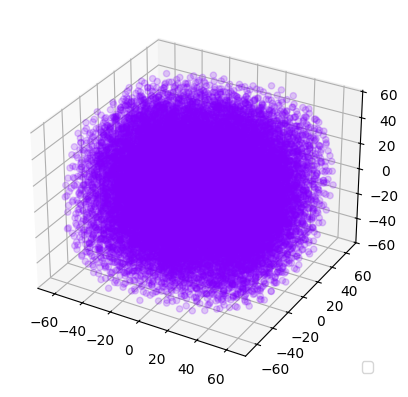

In [79]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
colors = cm.rainbow(np.linspace(0, 1, 1))
ax.scatter(plot_dt[:, 0], plot_dt[:, 1], plot_dt[:, 2], c=colors, alpha=0.2)
plt.legend(loc=4)
# plt.title("")
plt.show()

In [ ]:
# def tsne_plot_similar_words(labels, embedding_clusters, word_clusters, a=0.7):
#     plt.figure(figsize=(16, 9))
#     colors = cm.rainbow(np.linspace(0, 1, len(labels)))
#     for label, embeddings, words, color in zip(labels, embedding_clusters, word_clusters, colors):
#         x = embeddings[:,0]
#         y = embeddings[:,1]
#         plt.scatter(x, y, c=color, alpha=a, label=label)
#         for i, word in enumerate(words):
#             plt.annotate(word, alpha=0.5, xy=(x[i], y[i]), xytext=(5, 2), 
#                          textcoords='offset points', ha='right', va='bottom', size=8)
#     plt.legend(loc=4)
#     plt.grid(True)
#     plt.savefig("f/г.png", format='png', dpi=150, bbox_inches='tight')
#     plt.show()


# tsne_plot_similar_words(keys, embeddings_en_2d, word_clusters)

##### Scatterplot

In [38]:
#Select 10000 words from our vocabulary
from __future__ import absolute_import, division, print_function
import numpy as np
count = 10000
word_vectors_matrix = np.ndarray(shape=(count, 1000), dtype='float64')
word_list = []
i = 0
for word in model.wv.index_to_key:
    word_vectors_matrix[i] = model.wv[word]
    word_list.append(word)
    i = i+1
    if i == count:
        break
print("word_vectors_matrix shape is ", word_vectors_matrix.shape)

word_vectors_matrix shape is  (10000, 1000)


In [39]:
#Compress the word vectors into 2D space
import sklearn.manifold
tsne = sklearn.manifold.TSNE(n_components=2, random_state=0)
word_vectors_matrix_2d = tsne.fit_transform(word_vectors_matrix)
print("word_vectors_matrix_2d shape is ", word_vectors_matrix_2d.shape)

word_vectors_matrix_2d shape is  (10000, 2)


In [40]:
import pandas as pd
points = pd.DataFrame(
    [
        (word, coords[0], coords[1]) 
        for word, coords in [
            (word, word_vectors_matrix_2d[word_list.index(word)])
            for word in word_list
        ]
    ],
    columns=["word", "x", "y"]
)
print("Points DataFrame built")

Points DataFrame built


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_context("poster")

<Axes: xlabel='x', ylabel='y'>

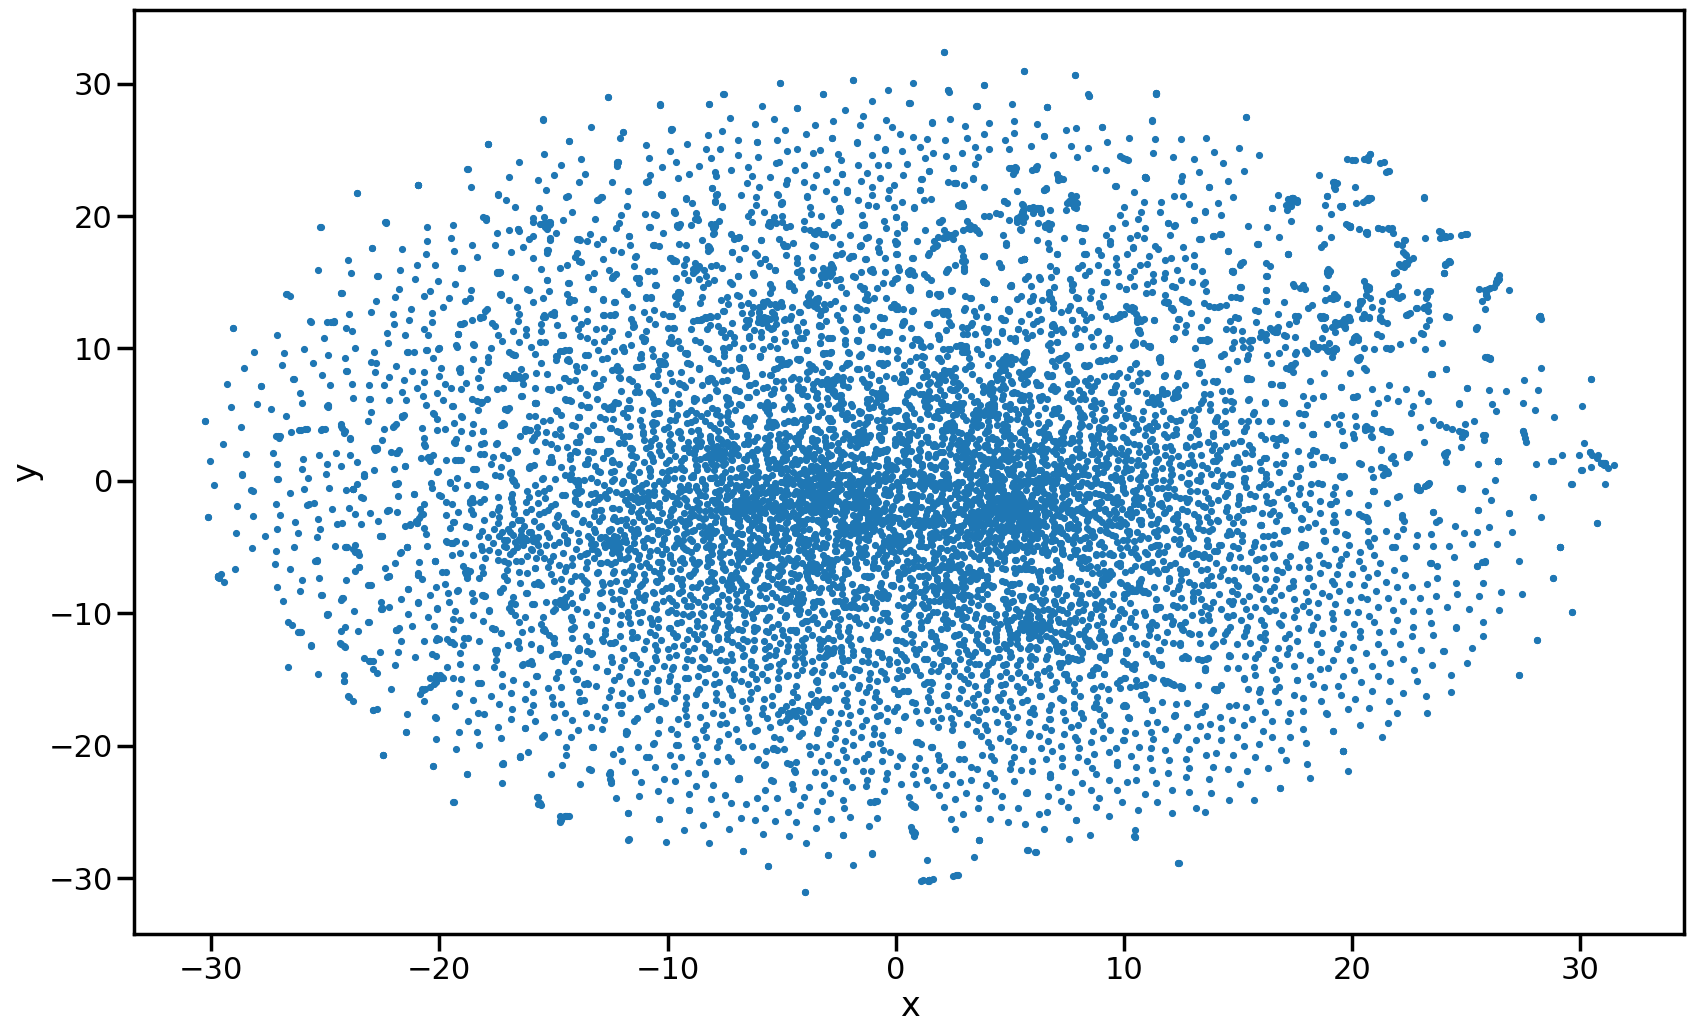

In [42]:
points.plot.scatter("x", "y", s=10, figsize=(20, 12))

In [43]:
def plot_region(x_bounds, y_bounds):
    slice = points[
        (x_bounds[0] <= points.x) &
        (points.x <= x_bounds[1]) &
        (y_bounds[0] <= points.y) &
        (points.y <= y_bounds[1]) 
    ]
    
    ax = slice.plot.scatter("x", "y", s=35, figsize=(10, 8))
    for i, point in slice.iterrows():
        ax.text(point.x + 0.005, point.y + 0.005, point.word, fontsize=11)

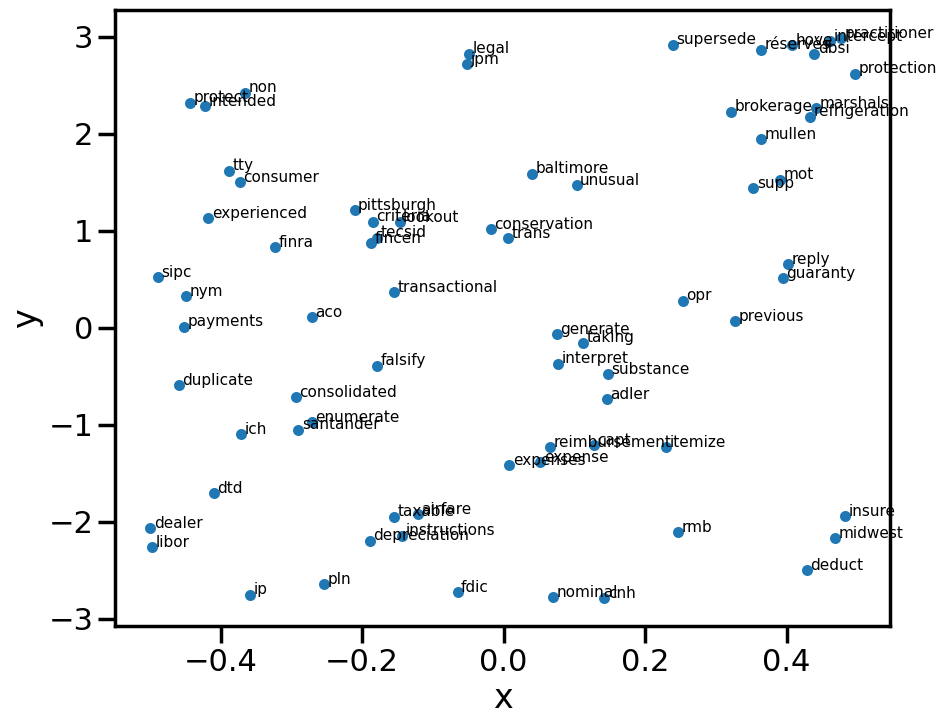

In [45]:
plot_region(x_bounds=(-.5, .5), y_bounds=(-3, 3))